In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [4]:
#at=> temp
#v=> vaccum
#ap=>pressure
#rh=>humidity
#pe=>produced energy

#1.load data
#2.data=>tensor
#3.tensor dataset and dataloader
#4.define ann nodel
#5.train model , save model
#6.evaluate

In [5]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [7]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [8]:
#split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [9]:
df.shape

(9568, 5)

In [10]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [12]:
import torch
import torch.nn as nn
#numoy = xtrainscaled,pandas=ytrain .values for directly accessing values of df
#view -1,1 changee dim rows,cols -1=765,1=1 col
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [13]:
#dataloader creates batches for us n shuffle , to define how data will be  loaded for train
#tensor dataset class :helper of dataloader, can access raw data from memory 


In [14]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [15]:
train_loader=DataLoader(train_dataset , batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset , batch_size=32)

In [16]:
#deeplearning
#defineour ann model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
        #1st hidden
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),
        #2 hidden layer
        nn.Linear(6,6),
        nn.ReLU(),
        #output layer
        nn.Linear(6,1),
       
    )
    def forward(self,x):
        return self.model(x)
        

In [17]:
import torch.optim as optim
model=ANN()
#loss,optimizer
criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters())



In [18]:
#train ann 
best_val_loss=float("inf")
train_losses=[]
val_losses=[]
epochs=100
for epoch in range (epochs):
    model.train()
    running_loss=0.0 #save total training loss for 1 epoch
    for xb,yb in train_loader:
        #xb=features of 1 batch ,yb=labels of 1 batch
        optimizer.zero_grad()
        output=model (xb) #forward prop ...predicted outputs for this batch
        loss=criterion(output,yb)
        loss.backward()#back prop..compute gradients 
        optimizer.step()#paras update
        running_loss+=loss.item()#loss is a tensor =>py float 
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #validation
    model.eval()
    running_val_loss=0.0
    with torch.no_grad():#no gard compute 
        
        for xb,yb in test_loader:
            output=model (xb) #forward prop ...predicted outputs for this batch
            loss=criterion(output,yb)

            running_val_loss+=loss#loss is a tensor =>py float 
        epoch_val_loss=running_val_loss/len(test_loader)
        val_losses.append(epoch_val_loss) 
        print(f"epoch ${epoch+1}/{epochs} ==> train loss =${epoch_train_loss} &val loss=${epoch_val_loss}")
        if epoch_val_loss<best_val_loss:
            best_val_loss=epoch_val_loss
            torch.save(model.state_dict(),"best_model.pt") # .pt or .pth
        

epoch $1/100 ==> train loss =$205935.7189453125 &val loss=$204508.5
epoch $2/100 ==> train loss =$199441.34348958332 &val loss=$189876.0
epoch $3/100 ==> train loss =$171011.6724609375 &val loss=$147157.53125
epoch $4/100 ==> train loss =$118005.16764322917 &val loss=$88463.2890625
epoch $5/100 ==> train loss =$63680.2181233724 &val loss=$43392.19921875
epoch $6/100 ==> train loss =$32188.07774251302 &val loss=$24656.1640625
epoch $7/100 ==> train loss =$21372.909549967448 &val loss=$18818.298828125
epoch $8/100 ==> train loss =$17274.43368733724 &val loss=$15408.9912109375
epoch $9/100 ==> train loss =$14006.679091389973 &val loss=$12269.9814453125
epoch $10/100 ==> train loss =$10946.329720052083 &val loss=$9287.59765625
epoch $11/100 ==> train loss =$8060.982192993164 &val loss=$6590.3974609375
epoch $12/100 ==> train loss =$5579.672758992513 &val loss=$4424.7138671875
epoch $13/100 ==> train loss =$3699.360524495443 &val loss=$2930.81982421875
epoch $14/100 ==> train loss =$2446.56

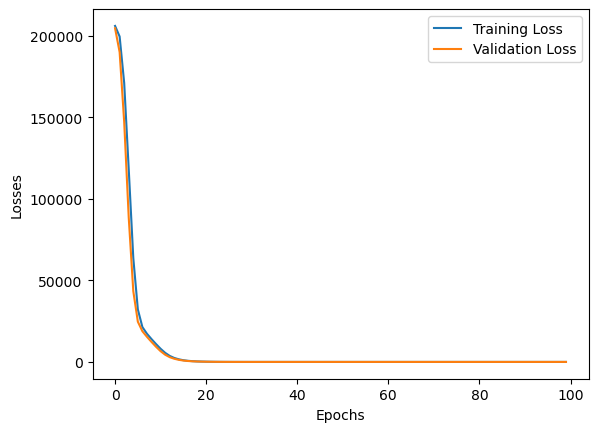

In [21]:
import matplotlib.pyplot as plt 
loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})
#plt.figure(figsize=(12,8))
plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [22]:
#loading the best model
model.load_state_dict(torch.load("best_model.pt"))


<All keys matched successfully>

In [24]:
#evaluate model
model.eval()
with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)
    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)
print("Training MSE:",train_mse_loss.item())
print("Testing MSE:",test_mse_loss.item())

Training MSE: 20.66259765625
Testing MSE: 18.913198471069336


In [26]:
from sklearn.metrics import r2_score
print("r^2 score=",r2_score(y_test,test_preds))

r^2 score= 0.9339032545510324


In [28]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])

actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)


,Predicted Values,Actual Values
0,435.285461,433.27
1,436.884705,438.16
2,460.959381,458.42
3,475.797913,480.82
4,435.249329,441.41
...,...,...
1909,451.191254,456.70
1910,431.647095,438.04
1911,467.345215,467.80
1912,431.079468,437.14
